In [1]:
import pandas as pd 
import numpy as np

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("data/all_tickets_processed_improved_v3.csv")

In [4]:
df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [5]:
df.columns

Index(['Document', 'Topic_group'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Document     47837 non-null  str  
 1   Topic_group  47837 non-null  str  
dtypes: str(2)
memory usage: 747.6 KB


In [7]:
df.shape

(47837, 2)

In [8]:
df.isnull().sum()

Document       0
Topic_group    0
dtype: int64

In [9]:
df.dropna()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous
...,...,...
47832,git space for a project issues with adding use...,Access
47833,error sent july error hi guys can you help out...,Miscellaneous
47834,connection issues sent tuesday july connection...,Hardware
47835,error cube reports sent tuesday july error hel...,HR Support


In [10]:
df["Topic_group"].value_counts()

Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64

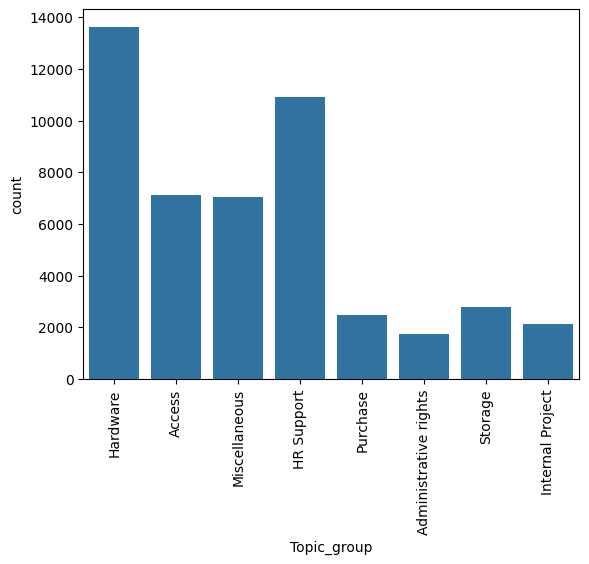

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# plt.figure(figsize = (6,8))
sns.countplot(x = "Topic_group",data = df)
plt.xticks(rotation= 90)
plt.show()

Data was inbalanced , it will affect the model perfomance

In [12]:
df['text_length'] = df['Document'].apply(len)
df['text_length'] .describe()

count    47837.000000
mean       291.881263
std        388.171200
min          7.000000
25%        110.000000
50%        175.000000
75%        304.000000
max       7015.000000
Name: text_length, dtype: float64

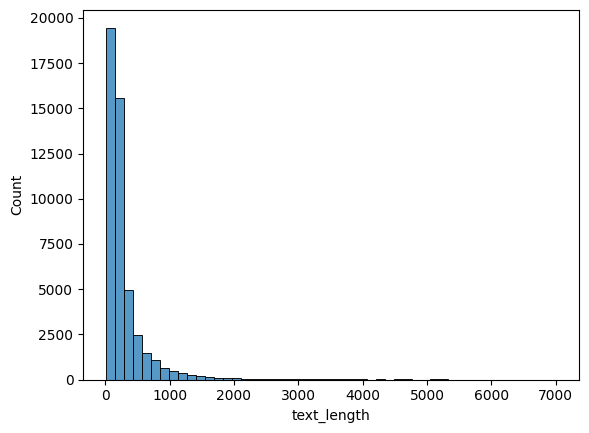

In [13]:
sns.histplot(df["text_length"],bins = 50)
plt.show()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df.drop_duplicates()

In [16]:
df.shape

(47837, 3)

In [26]:
df['Document'][0]

'connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead'

we can notice There are so many stop words and, noise and lowe case words and repeated phrases

#### Cleaning The Dataset Text

In [29]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df['cleaned_text'] = df['Document'].apply(clean_text)

In [32]:
df.head()

,Document,Topic_group,text_length,cleaned_text
0,connection with icon icon dear please setup ic...,Hardware,111,connection with icon icon dear please setup ic...
1,work experience user work experience user hi w...,Access,124,work experience user work experience user hi w...
2,requesting for meeting requesting meeting hi p...,Hardware,93,requesting for meeting requesting meeting hi p...
3,reset passwords for external accounts re expir...,Access,948,reset passwords for external accounts re expir...
4,mail verification warning hi has got attached ...,Miscellaneous,115,mail verification warning hi has got attached ...


##### Most Frequent Words

In [36]:
from collections import Counter

words = " ".join(df["cleaned_text"]).split()
common_words = Counter(words).most_common(20)

common_words

[('please', 70212),
 ('pm', 28902),
 ('hi', 28498),
 ('regards', 27212),
 ('thank', 24962),
 ('for', 24456),
 ('hello', 23025),
 ('you', 21828),
 ('re', 21034),
 ('thanks', 19852),
 ('sent', 14717),
 ('kind', 13241),
 ('access', 13153),
 ('help', 11173),
 ('tuesday', 10896),
 ('with', 10555),
 ('wednesday', 10428),
 ('dear', 10320),
 ('thursday', 9935),
 ('can', 9526)]

Lets Build the Word Cloud

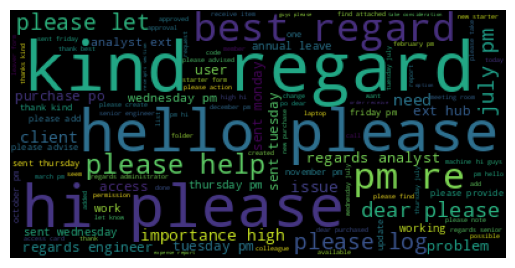

In [39]:
from wordcloud import WordCloud
wordcloud = WordCloud().generate(" ".join(df["cleaned_text"]))

plt.imshow(wordcloud)
plt.axis("off")
plt.show()


In [ ]:
print("Average Length:", df['text_length'].mean())
print("Max Length:", df['text_length'].max())
print("Min Length:", df['text_length'].min())

Average Length: 291.8812634571566
Max Length: 7015
Min Length: 7


In [45]:
import re

def noise_ratio(text):
    total_chars = len(text)
    clean_chars = len(re.sub(r'[^a-zA-Z\s]', '', text))
    return 1 - (clean_chars / total_chars)

df['noise_ratio'] = df['Document'].apply(noise_ratio)



In [49]:
df['noise_ratio'].value_counts()

noise_ratio
0.000000    47821
0.034188        1
0.055556        1
0.095238        1
0.051948        1
0.056338        1
0.058824        1
0.038462        1
0.057143        1
0.068966        1
0.054795        1
0.042553        1
0.041667        1
0.072727        1
0.050000        1
0.059701        1
0.074074        1
Name: count, dtype: int64

In [48]:

print("Average Noise_ratio:", df['noise_ratio'].mean())


Average Noise_ratio: 1.9068470543698906e-05


Lets find any Domain Specific Keywords

In [51]:
keywords = ['password','server','access','email','login','account']
for word in keywords:
    count = df["Document"].str.lower().str.contains(word).sum()
    print(f"{word} = {count}")

password = 1743
server = 1275
access = 9913
email = 0
login = 0
account = 3515


Incident Tickets

Category: Hardware, Software, Network, Security, Access, Services
Keywords: Connectivity Outage, Performance, VPN, Firewall, Router, Switch, Virus, Malware, Password Reset, Account Lockout, Email Disruption, Cloud Service Issues, Printing Services 
Service Request Tickets

Category: User Services, Hardware Requests, Software Requests, Access Requests, Information Requests, Communication Services, Facilities Services, Security Services, Collaboration Tools
Keywords: New Employee Onboarding, Laptop Provisioning, Software Installation, File Access, How-to Guides, Mobile Phone Setup, Access Card Issuance, Security Training, Email Distribution Lists, Video Conferencing Setup 
Problem Tickets

Category: Infrastructure, Software, Service, Security, User Experience, Process/Procedure
Keywords: Root Cause Analysis, Repeated Incident, Server Failures, Application Bugs, SLA Breaches, Usability Issues, Inefficient Workflows, Policy Gaps, Change Management Failures 
Change Request Tickets

Category: Standard Changes, Emergency Changes, Major Changes, Minor Changes, Service Request Changes, Regulatory and Compliance Changes, Infrastructure Changes, Application Changes, Security Changes
Keywords: Software Patches, Password Policy Updates, Critical Security Patches, New System Implementation, Data Center Migration, Enhanced Encryption, Minor Application Enhancements 
Ticket Management & Workflow Keywords

Keywords: Ticket Categorization, Prioritization, Incident Identification, Resolution Tracking, Post-Incident Analysis, Knowledge Article, SLA Compliance, Automation, Templates, Reporting, Root Cause Analysis (RCA)

In [55]:
for category in df["Topic_group"].unique():
    print(f"Category : {category}")
    subset = df[df["Topic_group"] == category]
    words = " ".join(subset['Document']).lower().split()
    common = Counter(words).most_common(10)
    print(common) 


Category : Hardware
[('please', 19401), ('you', 10095), ('hi', 9143), ('regards', 9038), ('for', 8909), ('re', 8778), ('pm', 7903), ('hello', 7666), ('thank', 7551), ('sent', 6741)]
Category : Access
[('please', 9006), ('confluence', 4587), ('pm', 4401), ('hi', 4001), ('regards', 3440), ('hello', 3182), ('thanks', 3150), ('thank', 3097), ('card', 2656), ('user', 2654)]
Category : Miscellaneous
[('please', 11258), ('hi', 4660), ('pm', 4605), ('change', 4390), ('for', 4354), ('regards', 4116), ('thank', 3866), ('hello', 3405), ('thanks', 3264), ('add', 3197)]
Category : HR Support
[('please', 16289), ('pm', 6477), ('thank', 6192), ('hi', 6092), ('for', 5950), ('leaver', 5646), ('regards', 5386), ('hello', 5383), ('error', 4778), ('form', 4570)]
Category : Purchase
[('please', 4744), ('purchase', 3792), ('po', 3764), ('administrator', 2112), ('log', 1943), ('regards', 1824), ('order', 1823), ('receive', 1660), ('kind', 1654), ('dear', 1640)]
Category : Administrative rights
[('upgrade', 2

There are Lots of Conversational Noise, BoilerPlate text  and Stopwords.

In [59]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
def remove_stopwords(text):
    words = text.split()
    filtered =  [word for word in words if word not in ENGLISH_STOP_WORDS]
    return " ".join(filtered)

In [60]:
df["cleaned_text"] = df["cleaned_text"].apply(remove_stopwords)
df["cleaned_text"]

0        connection icon icon dear setup icon icon engi...
1        work experience user work experience user hi w...
2        requesting meeting requesting meeting hi help ...
3        reset passwords external accounts expire days ...
4        mail verification warning hi got attached addr...
                               ...                        
47832    git space project issues adding users sent tue...
47833    error sent july error hi guys help error appea...
47834    connection issues sent tuesday july connection...
47835    error cube reports sent tuesday july error hel...
47836    running extensions hello advised running exten...
Name: cleaned_text, Length: 47837, dtype: str

In [61]:
for category in df["Topic_group"].unique():
    print(f"Category : {category}")
    subset = df[df["Topic_group"] == category]
    words = " ".join(subset['cleaned_text']).lower().split()
    common = Counter(words).most_common(10)
    print(common) 


Category : Hardware
[('hi', 9143), ('regards', 9038), ('pm', 7903), ('hello', 7666), ('thank', 7551), ('sent', 6741), ('thanks', 6067), ('access', 4773), ('issue', 4240), ('kind', 4082)]
Category : Access
[('confluence', 4587), ('pm', 4401), ('hi', 4001), ('regards', 3440), ('hello', 3182), ('thanks', 3150), ('thank', 3097), ('card', 2656), ('user', 2654), ('access', 2643)]
Category : Miscellaneous
[('hi', 4660), ('pm', 4605), ('change', 4390), ('regards', 4116), ('thank', 3866), ('hello', 3405), ('thanks', 3264), ('add', 3197), ('sent', 2297), ('kind', 1920)]
Category : HR Support
[('pm', 6477), ('thank', 6192), ('hi', 6092), ('leaver', 5646), ('regards', 5386), ('hello', 5383), ('error', 4778), ('form', 4570), ('starter', 4476), ('leave', 4215)]
Category : Purchase
[('purchase', 3792), ('po', 3764), ('administrator', 2112), ('log', 1943), ('regards', 1824), ('order', 1823), ('receive', 1660), ('kind', 1654), ('dear', 1640), ('purchased', 1639)]
Category : Administrative rights
[('upg

There was still some email Greetings and custom stopwords

In [62]:
custom_stopwords = ['hi','thank','regards','dear','hello','please','kind','pm','sent','re','fyi']


In [63]:
all_stopwords= ENGLISH_STOP_WORDS.union(custom_stopwords)
def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in all_stopwords]
    return " ".join(words)

df["cleaned_text"] = df["cleaned_text"].apply(remove_stopwords)

In [67]:
for category in df["Topic_group"].unique():
    print(f"Category : {category}")
    subset = df[df["Topic_group"] == category]
    words = " ".join(subset['cleaned_text']).lower().split()
    common = Counter(words).most_common(50)
    print(common) 


Category : Hardware
[('thanks', 6067), ('access', 4773), ('issue', 4240), ('help', 3927), ('tuesday', 3635), ('best', 3558), ('wednesday', 3413), ('thursday', 3306), ('engineer', 3166), ('friday', 3102), ('site', 3048), ('information', 2833), ('july', 2767), ('issues', 2701), ('si', 2688), ('ext', 2542), ('error', 2504), ('log', 2489), ('monitor', 2485), ('working', 2470), ('la', 2464), ('let', 2447), ('october', 2427), ('laptop', 2412), ('phone', 2386), ('work', 2376), ('client', 2270), ('meeting', 2221), ('senior', 2200), ('number', 2056), ('en', 2018), ('november', 1987), ('problem', 1976), ('report', 1879), ('update', 1852), ('provide', 1759), ('details', 1758), ('attached', 1688), ('high', 1671), ('analyst', 1667), ('december', 1660), ('ca', 1659), ('mobile', 1659), ('room', 1613), ('needed', 1584), ('updates', 1578), ('connect', 1542), ('server', 1535), ('test', 1533), ('need', 1529)]
Category : Access
[('confluence', 4587), ('thanks', 3150), ('card', 2656), ('user', 2654), ('acc

In [68]:
custom_stopwords = ['hi','thank','thanks','regards','dear','hello','please','kind','pm','sent','re','fyi','issuse','issuses','change','best','help',]


In [69]:
custom_stopwords = {
    # greetings
    'hi','hello','dear','thanks','thank','regards','please','kind',

    # email artifacts
    'pm','sent','re','fyi','attached',

    # generic useless words
    'issue','issues','help','best','need','needed','provide','provided',

    # time/date noise
    'monday','tuesday','wednesday','thursday','friday',
    'january','february','march','april','may','june','july',
    'august','september','october','november','december',

    # organizational noise
    'engineer','analyst','senior','client','team','manager',

    # misc low-signal
    'information','details','update','updated','report','reports',
    'let','know','number','ext','en','la','si'
}

In [70]:
all_stopwords = ENGLISH_STOP_WORDS.union(custom_stopwords)

In [71]:
df["cleaned_text"] = df["cleaned_text"].apply(remove_stopwords)
for category in df["Topic_group"].unique():
    print(f"Category : {category}")
    subset = df[df["Topic_group"] == category]
    words = " ".join(subset['cleaned_text']).lower().split()
    common = Counter(words).most_common(50)
    print(common) 


Category : Hardware
[('access', 4773), ('site', 3048), ('error', 2504), ('log', 2489), ('monitor', 2485), ('working', 2470), ('laptop', 2412), ('phone', 2386), ('work', 2376), ('meeting', 2221), ('problem', 1976), ('high', 1671), ('ca', 1659), ('mobile', 1659), ('room', 1613), ('updates', 1578), ('connect', 1542), ('server', 1535), ('test', 1533), ('message', 1526), ('date', 1519), ('order', 1481), ('old', 1461), ('request', 1450), ('connection', 1375), ('link', 1372), ('add', 1337), ('care', 1290), ('importance', 1282), ('available', 1274), ('floor', 1253), ('received', 1237), ('cable', 1219), ('change', 1194), ('make', 1168), ('hub', 1146), ('unable', 1134), ('possible', 1133), ('check', 1119), ('content', 1108), ('today', 1102), ('machine', 1088), ('va', 1084), ('required', 1074), ('developer', 1061), ('disk', 1057), ('assign', 1057), ('advise', 1052), ('note', 1045), ('lead', 1036)]
Category : Access
[('confluence', 4587), ('card', 2656), ('user', 2654), ('access', 2643), ('passwor

In [73]:
from collections import Counter

all_words = " ".join(df['cleaned_text']).split()
word_freq = Counter(all_words)

# Remove top frequent words dynamically
top_common = set([word for word, _ in word_freq.most_common(30)])

def remove_common(text):
    return " ".join([w for w in text.split() if w not in top_common])

df['clean_text'] = df['cleaned_text'].apply(remove_common)

In [76]:
for category in df["Topic_group"].unique():
    print(f"Category : {category}")
    subset = df[df["Topic_group"] == category]
    words = " ".join(subset['clean_text']).lower().split()
    common = Counter(words).most_common(50)
    print(common) 

Category : Hardware
[('monitor', 2485), ('laptop', 2412), ('phone', 2386), ('meeting', 2221), ('ca', 1659), ('mobile', 1659), ('room', 1613), ('updates', 1578), ('connect', 1542), ('server', 1535), ('test', 1533), ('message', 1526), ('old', 1461), ('connection', 1375), ('link', 1372), ('care', 1290), ('importance', 1282), ('available', 1274), ('floor', 1253), ('received', 1237), ('cable', 1219), ('make', 1168), ('hub', 1146), ('unable', 1134), ('possible', 1133), ('check', 1119), ('content', 1108), ('today', 1102), ('machine', 1088), ('va', 1084), ('required', 1074), ('developer', 1061), ('disk', 1057), ('assign', 1057), ('advise', 1052), ('note', 1045), ('lead', 1036), ('guys', 1029), ('files', 1024), ('screen', 971), ('id', 963), ('open', 954), ('application', 947), ('environment', 904), ('ticket', 886), ('users', 885), ('assigned', 883), ('ask', 881), ('file', 880), ('additional', 869)]
Category : Access
[('password', 2190), ('license', 1880), ('users', 1547), ('accounts', 1255), ('

lets remove semi-Noise words

In [77]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features = 5000, ngram_range=(1,2))

x = vectorizer.fit_transform(df['clean_text'])
y = df['Topic_group']
